# 🧪 Hamiltonian-VQE-Kit (`hvk`) — Chemistry & Pauli Quickstart

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aashiq-parinda/hamiltonian-vqe-kit/blob/main/notebooks/01_quickstart_chemistry.ipynb)
[![PyPI version](https://img.shields.io/pypi/v/hamiltonian-vqe-kit.svg?color=blue)](https://pypi.org/project/hamiltonian-vqe-kit/)
[![License: Apache-2.0](https://img.shields.io/badge/License-Apache--2.0-blue.svg)](https://github.com/aashiq-parinda/hamiltonian-vqe-kit/blob/main/LICENSE)

**Hamiltonian-VQE-Kit (`hvk`)** is an open-source, scientifically validated toolkit designed to take molecular and qubit Hamiltonians and synthesize transparent VQE and ADAPT-VQE setups capable of reaching **chemical accuracy (<= 1.6 mHa vs. Full CI)**.

### What this tutorial covers:
1. **Installing & importing `hvk`**
2. **Loading molecular systems** ($H_2$, $\text{LiH}$) with active spaces
3. **Jordan-Wigner transformations** into Pauli operators
4. **Verifying numerical parity** against PySCF Hartree-Fock and FCI exact references
5. **Computing and plotting a Potential Energy Surface (PES)**
6. **Performing native Pauli algebra, commutators, and exact eigensolvers**


# Install hvk with chemistry dependencies if running in Colab or a fresh environment
!pip install -q "hamiltonian-vqe-kit[chemistry]>=0.1.2" matplotlib

In [1]:
# Install hvk with chemistry dependencies if running in Colab or a fresh environment
!pip install -q "hamiltonian-vqe-kit[chemistry]>=0.1.2" matplotlib

### 2. Imports and Environment Check

In [2]:
import hvk
from hvk.chemistry import (
    load_h2,
    load_lih,
    load_beh2,
    load_molecule,
    validate_single_system,
    PauliSum,
    PauliTerm,
    parse_pauli_string,
)
import numpy as np
import matplotlib.pyplot as plt

print(f"Hamiltonian-VQE-Kit (hvk) Version: {hvk.__version__}")

Hamiltonian-VQE-Kit (hvk) Version: 0.1.2


### 3. Loading Molecular Systems & Active Spaces
Let's load a diatomic Hydrogen ($H_2$) molecule at equilibrium bond distance ($R = 0.7414\text{ Å}$) in an STO-3G minimal basis set.

In [3]:
h2 = load_h2(bond_distance=0.7414)

print(f"Molecule:            {h2.name} at R = {h2.bond_distance:.4f} Å")
print(f"Active Orbitals:     {h2.n_qubits // 2} spatial orbitals")
print(f"Active Electrons:    {h2.n_electrons}")
print(f"Jordan-Wigner Qubits:{h2.n_qubits} qubits")
print(f"Pauli Terms:         {len(h2.qubit_hamiltonian)} terms in qubit Hamiltonian")
print(f"PySCF RHF Energy:    {h2.e_hf_pyscf:.8f} Ha")
print(f"PySCF FCI Energy:    {h2.e_fci_pyscf:.8f} Ha")

Molecule:            H2 at R = 0.7414 Å
Active Orbitals:     2 spatial orbitals
Active Electrons:    2
Jordan-Wigner Qubits:4 qubits
Pauli Terms:         15 terms in qubit Hamiltonian
PySCF RHF Energy:    -1.11668439 Ha
PySCF FCI Energy:    -1.13727017 Ha


### 4. Inspecting the Jordan-Wigner Qubit Hamiltonian
The electronic Hamiltonian is mapped to a Hermitian linear combination of Pauli strings:
$$H = \sum_j c_j P_j, \quad P_j \in \{I, X, Y, Z\}^{\otimes N}$$

In [4]:
print(f"Total Pauli terms: {len(h2.qubit_hamiltonian)}\n")
print("First 8 terms of H2 Hamiltonian:")
for i, term in enumerate(h2.qubit_hamiltonian.terms[:8]):
    print(f"  [{i+1}] {term}")

Total Pauli terms: 15

First 8 terms of H2 Hamiltonian:
  [1] -0.098864 * I
  [2] +0.171198 * Z0
  [3] +0.171198 * Z1
  [4] -0.222786 * Z2
  [5] -0.222786 * Z3
  [6] +0.168622 * Z0 Z1
  [7] +0.120545 * Z0 Z2
  [8] +0.165867 * Z0 Z3


### 5. Validating Reference Parity (Honesty Rule #2)
Every molecular Hamiltonian in `hvk` is strictly verified against PySCF classical quantum chemistry references.
We test:
- **Hartree-Fock Parity**: Expectation value of the initial Slater determinant $|\Phi_{\text{HF}}\rangle$ matches PySCF RHF energy.
- **FCI Parity**: Exact ground-state eigenvalue matches PySCF Full CI (or CASCI) energy.


In [5]:
report = validate_single_system(h2, tolerance=1e-6)

print(f"Validation Status: {'✅ PASSED' if report['overall_passed'] else '❌ FAILED'}")
print(f"• PySCF RHF Reference:   {report['e_hf_pyscf']:.10f} Ha")
print(f"• Qubit HF State Energy: {report['e_hf_qubit']:.10f} Ha")
print(f"  Discrepancy (|ΔHF|):   {report['hf_diff_mha']:.2e} mHa")
print()
print(f"• PySCF FCI Reference:   {report['e_fci_pyscf']:.10f} Ha")
print(f"• Qubit Ground State:    {report['e_exact_qubit']:.10f} Ha")
print(f"  Discrepancy (|ΔFCI|):  {report['fci_diff_mha']:.2e} mHa")

Validation Status: ✅ PASSED
• PySCF RHF Reference:   -1.1166843871 Ha
• Qubit HF State Energy: -1.1166843871 Ha
  Discrepancy (|ΔHF|):   4.44e-13 mHa

• PySCF FCI Reference:   -1.1372701747 Ha
• Qubit Ground State:    -1.1372701747 Ha
  Discrepancy (|ΔFCI|):  1.78e-12 mHa


### 6. Potential Energy Surface (PES) Scan
Let's compute the Potential Energy Surface of $H_2$ as the bond distance stretches from $0.5\text{ Å}$ to $2.5\text{ Å}$.
Notice how Restricted Hartree-Fock (RHF) deviates from the exact FCI solution at larger bond distances (the Coulson-Fischer point), demonstrating the need for multireference correlation methods and VQE.

Scanning H2 Potential Energy Surface...


Scan complete! Plotting PES curve...


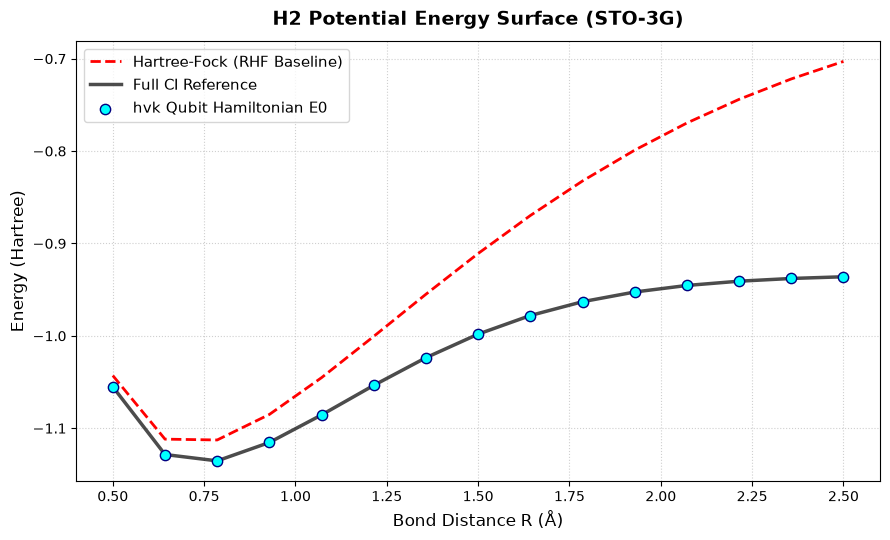

In [6]:
bond_distances = np.linspace(0.5, 2.5, 15)
rhf_energies = []
fci_energies = []
qubit_exact_energies = []

print("Scanning H2 Potential Energy Surface...")
for r in bond_distances:
    mol = load_h2(bond_distance=float(r))
    rhf_energies.append(mol.e_hf_pyscf)
    fci_energies.append(mol.e_fci_pyscf)
    
    e0, _ = mol.qubit_hamiltonian.exact_ground_state()
    qubit_exact_energies.append(e0)

print("Scan complete! Plotting PES curve...")

plt.figure(figsize=(9, 5.5))
plt.plot(bond_distances, rhf_energies, 'r--', label='Hartree-Fock (RHF Baseline)', linewidth=2)
plt.plot(bond_distances, fci_energies, 'k-', label='Full CI Reference', linewidth=2.5, alpha=0.7)
plt.scatter(bond_distances, qubit_exact_energies, color='cyan', edgecolors='navy', s=55, zorder=5, label='hvk Qubit Hamiltonian E0')

plt.title('H2 Potential Energy Surface (STO-3G)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Bond Distance R (Å)', fontsize=12)
plt.ylabel('Energy (Hartree)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, frameon=True)
plt.tight_layout()
plt.show()

### 7. Multi-Molecule Active Spaces: Lithium Hydride ($LiH$)
For molecules with core electrons, `hvk` supports frozen-core Complete Active Space (CAS) definitions.
For $LiH$, freezing the Li $1s^2$ core leaves $2$ active electrons in $3$ spatial orbitals, mapped to $6$ qubits:

In [7]:
lih = load_lih(bond_distance=1.595)

print(f"Molecule:            {lih.name} (CAS 2e, 3o)")
print(f"Bond Distance:       {lih.bond_distance:.4f} Å")
print(f"Qubits:              {lih.n_qubits} qubits")
print(f"Pauli Terms:         {len(lih.qubit_hamiltonian)} terms")
print(f"Active HF Energy:    {lih.e_hf_pyscf:.8f} Ha")
print(f"Active CASCI Energy: {lih.e_fci_pyscf:.8f} Ha")

lih_report = validate_single_system(lih, tolerance=1e-6)
print(f"LiH Reference Parity: {'✅ PASSED' if lih_report['overall_passed'] else '❌ FAILED'}")

Molecule:            LiH (CAS 2e, 3o)
Bond Distance:       1.5950 Å
Qubits:              6 qubits
Pauli Terms:         62 terms
Active HF Energy:    -7.86202386 Ha
Active CASCI Energy: -7.86307775 Ha
LiH Reference Parity: ✅ PASSED


### 8. Native Pauli Algebra & Commutator Calculus
`hvk.chemistry.pauli` provides a standalone algebra engine for Pauli strings, expectations, and commutators $[A, B]$:

In [8]:
# Parse custom Hamiltonian strings
h_custom = parse_pauli_string("0.5 * Z0 Z1 - 0.25 * X0 X1 + 1.25 * I", n_qubits=2)
print("Parsed Hamiltonian:")
print(h_custom)

# Compute expectation value on state |00>
state_00 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
exp_val = h_custom.expectation_value(state_00)
print(f"\nExpectation value <00| H |00>: {exp_val:.4f} Ha")

# Exact ground state energy via eigensolver
e_ground, psi_ground = h_custom.exact_ground_state()
print(f"Exact Ground State Energy: {e_ground:.6f} Ha")

Parsed Hamiltonian:
+0.500000 * Z0 Z1
-0.250000 * X0 X1
+1.250000 * I

Expectation value <00| H |00>: 1.7500 Ha
Exact Ground State Energy: 0.500000 Ha


---
### 🚀 Summary & Next Steps
You have loaded molecular systems, synthesized Jordan-Wigner qubit Hamiltonians, verified sub-microHartree parity with PySCF references, and scanned potential energy surfaces!

- **GitHub Repository**: [github.com/aashiq-parinda/hamiltonian-vqe-kit](https://github.com/aashiq-parinda/hamiltonian-vqe-kit)
- **PyPI Package**: `pip install hamiltonian-vqe-kit`
- **Next Tutorial**: Operator pools and the exact ADAPT-VQE algorithm engine!
